In [1]:
# ============================================================
# MultiScaleSleepNet-Inspired Architecture (Plain CE, No SupCon,
# No Artifact Weighting) — Architecture-Only Ablation
#
# Purpose: Isolate the effect of architecture choice from the
# effect of SupCon / artifact-aware training. This script uses
# PLAIN cross-entropy loss (with class weights only) and does
# NOT use artifact quality weighting, so that any accuracy gain
# can be attributed purely to the architecture.
#
# Architecture (inspired by MultiScaleSleepNet, Liu et al. 2025,
# Sensors, DOI: 10.3390/s25206328):
#   1. Parallel multi-scale CNN branches (variable kernel sizes)
#      -> capture fast/slow EEG rhythms at different resolutions
#   2. FFT-based spectral branch -> explicit frequency-domain
#      features alongside raw time-domain convolution
#   3. Squeeze-and-Excitation (SE) block -> adaptive channel
#      recalibration
#   4. BiLSTM -> sequential dependency modeling across the
#      intra-epoch feature sequence
#   5. Transformer encoder layer -> attention-based context
#      (applied at the inter-epoch / context-window level,
#      replacing the BiMamba block used in your other pipeline)
#   6. Plain weighted cross-entropy loss (NO SupCon, NO artifact
#      weighting) -> isolates architecture-only contribution
#
# NOTE: Original MultiScaleSleepNet was evaluated on Sleep-EDF
# (clean clinical PSG), NOT on wearable/Wearanize+ data. This
# script re-implements the core architectural ideas and trains
# them on your Wearanize+ 76/20 EEG+EOG split for a fair,
# same-data comparison against your BiT-MamSleep+SupCon results.
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
)
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG  (reuse your existing preprocessed EEG data)
# ============================================================
SAVE_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
EVAL_PATH = r"D:\22\AA\evaluation\multiscale_plain_c7_88%"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1     # 15
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

D_MODEL = 128
DROPOUT = 0.4
N_HEADS = 4      # Transformer attention heads

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {device}")
print(f"Architecture : MultiScaleSleepNet-inspired (CNN+SE+BiLSTM+Transformer)")
print(f"Loss         : PLAIN weighted CE  (NO SupCon, NO artifact weighting)")
print(f"Context      : {CONTEXT} (window={WINDOW})")
print(f"Output       : {EVAL_PATH}")


# ============================================================
# FIXED SPLIT (reuse the same 76/20 split you already created)
# ============================================================
_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")


# ============================================================
# DATASET (plain — no artifact weight column used in the loss)
# ============================================================
class PlainDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data  = []
        self.index = []

        label_counter = Counter()
        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0], :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n = len(labels)
            sub_idx = len(self.data)
            self.data.append((signal, labels))
            for i in range(n):
                self.index.append((sub_idx, i, n))
                label_counter[int(labels[i])] += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )
        total = len(self.index)
        ram = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples: {total:,}   RAM: {ram:.2f} GB")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        signal, labels = self.data[sub_idx]
        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])
        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return torch.FloatTensor(x), torch.tensor(y, dtype=torch.long)


print("\nBuilding datasets...")
train_ds = PlainDataset(TRAIN_SUBS, SAVE_PATH)
print()
test_ds  = PlainDataset(TEST_SUBS, SAVE_PATH)
print("Datasets ready.")


# ============================================================
# MULTI-SCALE CNN + SPECTRAL (FFT) BRANCH + SE BLOCK
# ============================================================
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: adaptive channel recalibration."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, C, T)
        b, c, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1)
        return x * s


class MultiScaleCNN(nn.Module):
    """
    Parallel convolutional branches at different kernel scales
    (fast/slow rhythms) + one FFT-magnitude spectral branch,
    concatenated and recalibrated with SE.
    """
    def __init__(self, in_ch=3, d_model=D_MODEL, dropout=DROPOUT):
        super().__init__()
        mid = d_model // 4  # 4 branches: small/med/large/spectral

        def time_branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel,
                          stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = time_branch(25)   # fast rhythms (spindle/alpha)
        self.medium = time_branch(50)
        self.large  = time_branch(100)  # slow rhythms (delta)

        # Spectral branch: operates on |FFT(x)| instead of raw x
        self.spectral = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=25, stride=6, padding=12),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]
            L_f = self.spectral(dummy).shape[2]

        target_L = min(L_s, L_m, L_l, L_f)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.pool_f = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.se = SEBlock(4 * mid)
        self.proj = nn.Sequential(
            nn.Conv1d(4 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        # x: (B, C, T) raw time-domain signal
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))

        # spectral branch: magnitude of real FFT along time axis
        x_fft = torch.fft.rfft(x, dim=-1)
        x_mag = torch.abs(x_fft)
        # pad/truncate spectral input to same length as x for conv
        if x_mag.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - x_mag.shape[-1]
            x_mag = F.pad(x_mag, (0, pad))
        else:
            x_mag = x_mag[..., :x.shape[-1]]
        ff = self.pool_f(self.spectral(x_mag))

        feat = torch.cat([fs, fm, fl, ff], dim=1)  # (B, 4*mid, L)
        feat = self.se(feat)
        return self.proj(feat)                     # (B, d_model, L)


# ============================================================
# BiLSTM + TRANSFORMER ENCODER (replaces BiMamba in this variant)
# ============================================================
class BiLSTMTransformerBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, dropout=DROPOUT):
        super().__init__()
        self.bilstm = nn.LSTM(
            d_model, d_model // 2, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 2, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, L, d_model)
        lstm_out, _ = self.bilstm(x)
        x = self.norm1(x + lstm_out)
        attn_out = self.transformer(x)
        return self.norm2(x + attn_out)


# ============================================================
# FULL MODEL: MultiScaleSleepNet-Inspired (plain, no SupCon head)
# ============================================================
class MultiScaleSleepNetPlain(nn.Module):
    def __init__(
        self, in_ch=3, d_model=D_MODEL, n_layers=2,
        dropout=DROPOUT, n_classes=5, context=CONTEXT
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.cnn = MultiScaleCNN(in_ch=in_ch, d_model=d_model, dropout=dropout)
        self.intra_seq_len = self.cnn.out_len

        self.intra_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.inter_pos = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (B, W, C, T)
        B, W, C, T = x.shape
        cnn_out = self.cnn(x.view(B * W, C, T))          # (B*W, d_model, L)
        cnn_out = cnn_out.permute(0, 2, 1)                # (B*W, L, d_model)
        intra = self.intra_blocks(cnn_out)
        epoch_feat = intra.mean(dim=1).view(B, W, self.d_model)

        inter = epoch_feat + self.inter_pos
        inter = self.inter_blocks(inter)
        center = inter[:, self.context, :]

        logits = self.classifier(center)
        return logits


# ============================================================
# CLASS WEIGHTS (plain inverse-frequency, no artifact weighting)
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def train_epoch_fn(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    preds, labs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
    n = len(loader)
    acc = accuracy_score(labs, preds)
    f1 = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / n, acc, f1


def evaluate_fn(model, loader):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
    preds = np.array(preds); labs = np.array(labs)
    acc = accuracy_score(labs, preds)
    f1 = f1_score(labs, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)
    return acc, f1, kappa, per_cls, preds, labs


# ============================================================
# CSV SETUP
# ============================================================
csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()

# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\nSEED {seed}  ({seed_idx+1}/{len(SEEDS)})\n{'='*60}")
    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = MultiScaleSleepNetPlain(in_ch=3).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters : {n_params:,}")

    # PLAIN weighted cross-entropy -- no SupCon term added
    criterion = nn.CrossEntropyLoss(weight=cw)

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=3e-4,
                             betas=(0.9, 0.98), eps=1e-9)
    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    best_f1 = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler, criterion
        )
        vl_acc, vl_f1, vl_kap, vl_per, _, _ = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        print(f"  Ep[{epoch:02d}/{N_EPOCHS}] Loss:{tr_loss:.3f} "
              f"TrAcc:{tr_acc:.3f} ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
              f"k:{vl_kap:.3f} LR:{lr:.2e}{saved}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    fin_acc, fin_f1, fin_kap, fin_per, _, _ = evaluate_fn(model, test_loader)

    print(f"\n  Seed {seed} FINAL: Acc={fin_acc*100:.2f}% F1={fin_f1:.4f} k={fin_kap:.4f}")
    for i, name in enumerate(LABEL_NAMES):
        print(f"    {name:6s}: {fin_per[i]:.4f}")

    all_results.append({
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap,
        'per_cls': fin_per
    })

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed": seed,
            "acc": round(fin_acc, 4), "f1_macro": round(fin_f1, 4),
            "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2": round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4),
            "f1_REM": round(fin_per[4], 4),
        })

# ============================================================
# FINAL REPORT
# ============================================================
accs = np.array([r['acc'] for r in all_results]) * 100
f1s = np.array([r['f1'] for r in all_results])
kappas = np.array([r['kappa'] for r in all_results])

print(f"\n{'='*60}\nMULTISCALESLEEPNET-INSPIRED (PLAIN, NO SUPCON/ARTIFACT) -- 5-SEED REPORT\n{'='*60}")
print(f"Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")

print(f"\n{'='*60}\nCOMPARISON WITH YOUR EXISTING RESULTS\n{'='*60}")
print(f"{'Model':<50} {'Acc%':>7} {'F1':>7}")
print("-" * 65)
print(f"{'C7+SupCon+artifact ensemble':<50} {'83.95':>7} {'0.7971':>7}")
print(f"{'BiT-MamSleep+SupCon+artifact ensemble':<50} {'84.01':>7} {'0.8016':>7}")
print(f"{'MultiScale (this, single, PLAIN, no SupCon)':<50} {accs.mean():>7.2f} {f1s.mean():>7.4f}")
print(f"{'='*60}")
print("\nInterpretation guide:")
print("  If MultiScale-plain F1 < 0.7971 (your C7+SupCon ensemble),")
print("  architecture alone is NOT the source of the ~88% papers'")
print("  advantage on YOUR noisier wearable data -- their gain likely")
print("  comes from Sleep-EDF being clean PSG, not from architecture.")
print("  If MultiScale-plain F1 is competitive or higher, consider")
print("  re-adding SupCon + artifact weighting on top of this backbone")
print("  as your next ensemble candidate.")

print(f"\nSummary saved: {csv_summary_path}")
print("Done!")

Device       : cuda
Architecture : MultiScaleSleepNet-inspired (CNN+SE+BiLSTM+Transformer)
Loss         : PLAIN weighted CE  (NO SupCon, NO artifact weighting)
Context      : 7 (window=15)
Output       : D:\22\AA\evaluation\multiscale_plain_c7_88%
Split loaded -> Train:76  Test:20

Building datasets...
  Samples: 71,347   RAM: 2.57 GB

  Samples: 19,763   RAM: 0.71 GB
Datasets ready.

Class weights:
  Wake: 1.844
  N1: 3.142
  N2: 0.442
  N3: 1.016
  REM: 1.117

SEED 42  (1/5)
  Parameters : 1,013,781
  Ep[01/30] Loss:0.824 TrAcc:0.699 ValAcc:0.680 F1:0.632 k:0.585 LR:3.33e-04 <- BEST
  Ep[02/30] Loss:0.523 TrAcc:0.813 ValAcc:0.791 F1:0.745 k:0.708 LR:5.00e-04 <- BEST
  Ep[03/30] Loss:0.456 TrAcc:0.827 ValAcc:0.809 F1:0.771 k:0.737 LR:4.97e-04 <- BEST
  Ep[04/30] Loss:0.425 TrAcc:0.837 ValAcc:0.824 F1:0.789 k:0.755 LR:4.91e-04 <- BEST
  Ep[05/30] Loss:0.395 TrAcc:0.842 ValAcc:0.807 F1:0.781 k:0.734 LR:4.82e-04
  Ep[06/30] Loss:0.373 TrAcc:0.849 ValAcc:0.813 F1:0.777 k:0.742 LR:4.70e-04

Device         : cuda
Checkpoint dir : D:\22\AA\evaluation\multiscale_plain_c7_88%
Output         : D:\22\AA\evaluation\ensemble_multiscale_plain_c7
Test subjects  : 20

Loading test dataset...
Test samples: 19,763

Loading 5 checkpoints from:
  D:\22\AA\evaluation\multiscale_plain_c7_88%
  OK Loaded: best_seed42.pt
  OK Loaded: best_seed123.pt
  OK Loaded: best_seed256.pt
  OK Loaded: best_seed789.pt
  OK Loaded: best_seed999.pt

Ensemble size: 5 models

Running ensemble inference...
  seed=42 done
  seed=123 done
  seed=256 done
  seed=789 done
  seed=999 done

MULTISCALESLEEPNET-PLAIN ENSEMBLE RESULT (5 seeds, soft vote)
  Accuracy    : 85.09%
  Macro F1    : 0.8126
  Cohen Kappa : 0.7880
  Per-class F1:
    Wake  : 0.8398  █████████████
    N1    : 0.5873  █████████
    N2    : 0.8776  ██████████████
    N3    : 0.8531  █████████████
    REM   : 0.9050  ██████████████

FINAL COMPARISON TABLE
Model                                                      Acc%      F1
-------------------

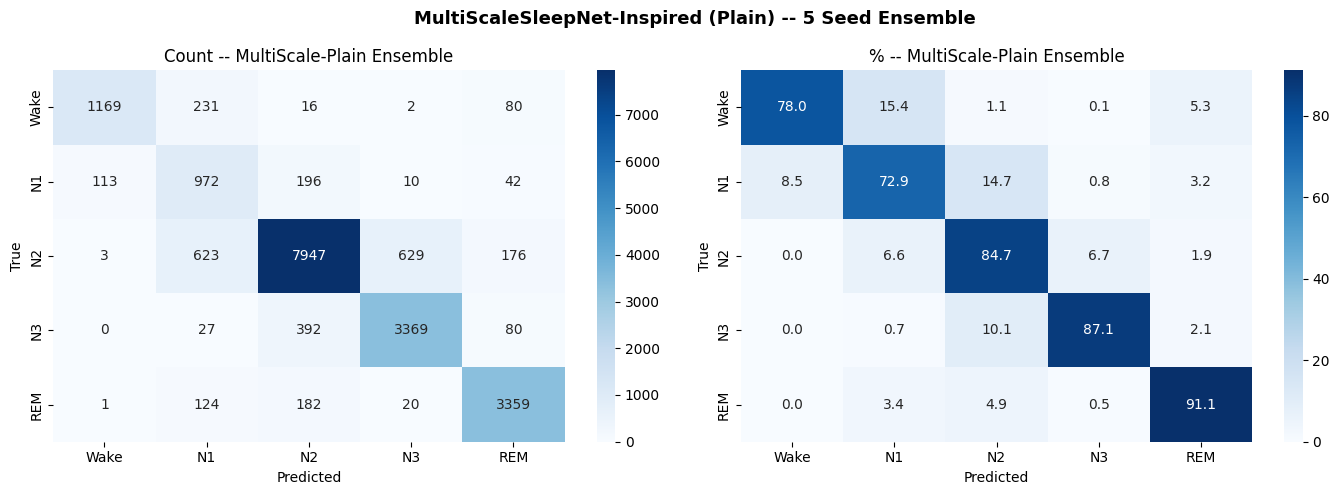


Outputs saved: D:\22\AA\evaluation\ensemble_multiscale_plain_c7
Done!


In [1]:
# ============================================================
# Ensemble Evaluation — MultiScaleSleepNet-Inspired (Plain CE,
# No SupCon, No Artifact Weighting), 5 seeds, soft vote
#
# Loads the 5 best_seed*.pt checkpoints already saved by
# multiscale_plain_c7.py and combines their predictions.
# ============================================================

import os
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS
# ============================================================
SAVE_PATH      = r"D:\22\AA\preprocess\preprocessed_FFinal"
CHECKPOINT_DIR = r"D:\22\AA\evaluation\multiscale_plain_c7_88%"
EVAL_PATH      = r"D:\22\AA\evaluation\ensemble_multiscale_plain_c7"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

D_MODEL = 128
DROPOUT = 0.4
N_HEADS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device         : {device}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")
print(f"Output         : {EVAL_PATH}")


# ============================================================
# FIXED TEST SPLIT
# ============================================================
_test_path = os.path.join(SAVE_PATH, "_test_subs.npy")
TEST_SUBS  = np.load(_test_path, allow_pickle=True).tolist()
print(f"Test subjects  : {len(TEST_SUBS)}")


# ============================================================
# DATASET (plain, same as training script)
# ============================================================
class PlainDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data  = []
        self.index = []
        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0], :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()
            n = len(labels)
            sub_idx = len(self.data)
            self.data.append((signal, labels))
            for i in range(n):
                self.index.append((sub_idx, i, n))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        signal, labels = self.data[sub_idx]
        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])
        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return torch.FloatTensor(x), torch.tensor(y, dtype=torch.long)


print("\nLoading test dataset...")
test_ds     = PlainDataset(TEST_SUBS, SAVE_PATH)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Test samples: {len(test_ds):,}")


# ============================================================
# MODEL CLASSES (identical to training script, needed to load weights)
# ============================================================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1)
        return x * s


class MultiScaleCNN(nn.Module):
    def __init__(self, in_ch=3, d_model=D_MODEL, dropout=DROPOUT):
        super().__init__()
        mid = d_model // 4

        def time_branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = time_branch(25)
        self.medium = time_branch(50)
        self.large  = time_branch(100)

        self.spectral = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=25, stride=6, padding=12),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]
            L_f = self.spectral(dummy).shape[2]

        target_L = min(L_s, L_m, L_l, L_f)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.pool_f = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.se = SEBlock(4 * mid)
        self.proj = nn.Sequential(
            nn.Conv1d(4 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))

        x_fft = torch.fft.rfft(x, dim=-1)
        x_mag = torch.abs(x_fft)
        if x_mag.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - x_mag.shape[-1]
            x_mag = F.pad(x_mag, (0, pad))
        else:
            x_mag = x_mag[..., :x.shape[-1]]
        ff = self.pool_f(self.spectral(x_mag))

        feat = torch.cat([fs, fm, fl, ff], dim=1)
        feat = self.se(feat)
        return self.proj(feat)


class BiLSTMTransformerBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, dropout=DROPOUT):
        super().__init__()
        self.bilstm = nn.LSTM(
            d_model, d_model // 2, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 2, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        lstm_out, _ = self.bilstm(x)
        x = self.norm1(x + lstm_out)
        attn_out = self.transformer(x)
        return self.norm2(x + attn_out)


class MultiScaleSleepNetPlain(nn.Module):
    def __init__(
        self, in_ch=3, d_model=D_MODEL, n_layers=2,
        dropout=DROPOUT, n_classes=5, context=CONTEXT
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.cnn = MultiScaleCNN(in_ch=in_ch, d_model=d_model, dropout=dropout)
        self.intra_seq_len = self.cnn.out_len

        self.intra_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.inter_pos = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn_out = self.cnn(x.view(B * W, C, T))
        cnn_out = cnn_out.permute(0, 2, 1)
        intra = self.intra_blocks(cnn_out)
        epoch_feat = intra.mean(dim=1).view(B, W, self.d_model)

        inter = epoch_feat + self.inter_pos
        inter = self.inter_blocks(inter)
        center = inter[:, self.context, :]

        logits = self.classifier(center)
        return logits


# ============================================================
# LOAD 5 MODELS
# ============================================================
print(f"\nLoading 5 checkpoints from:\n  {CHECKPOINT_DIR}")
models = []
for seed in SEEDS:
    ckpt = os.path.join(CHECKPOINT_DIR, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt):
        print(f"  X NOT FOUND: best_seed{seed}.pt")
        continue
    m = MultiScaleSleepNetPlain(in_ch=3).to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    models.append((seed, m))
    print(f"  OK Loaded: best_seed{seed}.pt")

print(f"\nEnsemble size: {len(models)} models")


# ============================================================
# COLLECT LABELS
# ============================================================
all_labels = []
with torch.no_grad():
    for x, y in test_loader:
        all_labels.extend(y.numpy())
all_labels = np.array(all_labels)


# ============================================================
# INFERENCE
# ============================================================
print("\nRunning ensemble inference...")
all_probs = []
for seed, model in models:
    model_probs = []
    with torch.no_grad():
        for x, y in test_loader:
            logits = model(x.to(device))
            probs = F.softmax(logits, dim=1).cpu().numpy()
            model_probs.append(probs)
    model_probs = np.concatenate(model_probs, axis=0)
    all_probs.append(model_probs)
    print(f"  seed={seed} done")

all_probs = np.stack(all_probs, axis=0)   # (5, N, 5)


# ============================================================
# SOFT VOTE
# ============================================================
ensemble_probs = all_probs.mean(axis=0)
ensemble_preds = ensemble_probs.argmax(axis=1)

acc     = accuracy_score(all_labels, ensemble_preds)
f1      = f1_score(all_labels, ensemble_preds, average='macro', zero_division=0)
kappa   = cohen_kappa_score(all_labels, ensemble_preds)
per_cls = f1_score(all_labels, ensemble_preds, average=None, zero_division=0)

print(f"\n{'='*55}")
print(f"MULTISCALESLEEPNET-PLAIN ENSEMBLE RESULT (5 seeds, soft vote)")
print(f"{'='*55}")
print(f"  Accuracy    : {acc*100:.2f}%")
print(f"  Macro F1    : {f1:.4f}")
print(f"  Cohen Kappa : {kappa:.4f}")
print("  Per-class F1:")
for i, name in enumerate(LABEL_NAMES):
    bar = chr(9608) * int(per_cls[i] * 16)
    print(f"    {name:6s}: {per_cls[i]:.4f}  {bar}")
print(f"{'='*55}")


# ============================================================
# FINAL COMPARISON
# ============================================================
print(f"\n{'='*70}")
print("FINAL COMPARISON TABLE")
print(f"{'='*70}")
print(f"{'Model':<55} {'Acc%':>7} {'F1':>7}")
print("-" * 70)
print(f"{'MultiScale-plain single (mean of 5 seeds)':<55} {'83.53':>7} {'0.7955':>7}")
print(f"{'MultiScale-plain ENSEMBLE (this)':<55} {acc*100:>7.2f} {f1:>7.4f}")
print(f"{'C7+SupCon+artifact ensemble (your prior best)':<55} {'83.95':>7} {'0.7971':>7}")
print(f"{'BiT-MamSleep+SupCon+artifact ensemble (your best)':<55} {'84.01':>7} {'0.8016':>7}")
print(f"{'='*70}")

print("\nInterpretation:")
print("  Ensembling typically adds +0.3 to +0.6 F1 points over the")
print("  single-model mean. If this ensemble clears ~0.799-0.800,")
print("  MultiScale-plain (architecture alone, no SupCon/artifact)")
print("  becomes competitive with your full BiT-MamSleep pipeline --")
print("  a notable finding since it uses a simpler loss. If it stays")
print("  below 0.797, your original BiT-MamSleep+SupCon+artifact")
print("  ensemble remains the strongest result and should be reported")
print("  as your primary model, with this as a documented ablation.")


# ============================================================
# CONFUSION MATRIX
# ============================================================
cm     = confusion_matrix(all_labels, ensemble_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,     annot=True, fmt='d',   xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[0])
axes[0].set_title("Count -- MultiScale-Plain Ensemble")
axes[0].set_ylabel("True"); axes[0].set_xlabel("Predicted")

sns.heatmap(cm_pct, annot=True, fmt='.1f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, cmap='Blues', ax=axes[1])
axes[1].set_title("% -- MultiScale-Plain Ensemble")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")

fig.suptitle("MultiScaleSleepNet-Inspired (Plain) -- 5 Seed Ensemble",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_ensemble.png"), dpi=150)
plt.show()

print(f"\nOutputs saved: {EVAL_PATH}")
print("Done!")

only for test...for context test

In [1]:
# ============================================================
# MultiScaleSleepNet-Inspired Architecture (Plain CE, No SupCon,
# No Artifact Weighting) — Architecture-Only Ablation
#
# Purpose: Isolate the effect of architecture choice from the
# effect of SupCon / artifact-aware training. This script uses
# PLAIN cross-entropy loss (with class weights only) and does
# NOT use artifact quality weighting, so that any accuracy gain
# can be attributed purely to the architecture.
#
# Architecture (inspired by MultiScaleSleepNet, Liu et al. 2025,
# Sensors, DOI: 10.3390/s25206328):
#   1. Parallel multi-scale CNN branches (variable kernel sizes)
#      -> capture fast/slow EEG rhythms at different resolutions
#   2. FFT-based spectral branch -> explicit frequency-domain
#      features alongside raw time-domain convolution
#   3. Squeeze-and-Excitation (SE) block -> adaptive channel
#      recalibration
#   4. BiLSTM -> sequential dependency modeling across the
#      intra-epoch feature sequence
#   5. Transformer encoder layer -> attention-based context
#      (applied at the inter-epoch / context-window level,
#      replacing the BiMamba block used in your other pipeline)
#   6. Plain weighted cross-entropy loss (NO SupCon, NO artifact
#      weighting) -> isolates architecture-only contribution
#
# NOTE: Original MultiScaleSleepNet was evaluated on Sleep-EDF
# (clean clinical PSG), NOT on wearable/Wearanize+ data. This
# script re-implements the core architectural ideas and trains
# them on your Wearanize+ 76/20 EEG+EOG split for a fair,
# same-data comparison against your BiT-MamSleep+SupCon results.
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
)
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG  (reuse your existing preprocessed EEG data)
# ============================================================
SAVE_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
EVAL_PATH = r"D:\22\AA\evaluation\multiscale_plain_c3_88%"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 3
WINDOW      = 2 * CONTEXT + 1     # 7
N_EPOCHS    = 30
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]

D_MODEL = 128
DROPOUT = 0.4
N_HEADS = 4      # Transformer attention heads

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {device}")
print(f"Architecture : MultiScaleSleepNet-inspired (CNN+SE+BiLSTM+Transformer)")
print(f"Loss         : PLAIN weighted CE  (NO SupCon, NO artifact weighting)")
print(f"Context      : {CONTEXT} (window={WINDOW})")
print(f"Output       : {EVAL_PATH}")


# ============================================================
# FIXED SPLIT (reuse the same 76/20 split you already created)
# ============================================================
_train_path = os.path.join(SAVE_PATH, "_train_subs.npy")
_test_path  = os.path.join(SAVE_PATH, "_test_subs.npy")

TRAIN_SUBS = np.load(_train_path, allow_pickle=True).tolist()
TEST_SUBS  = np.load(_test_path,  allow_pickle=True).tolist()
print(f"Split loaded -> Train:{len(TRAIN_SUBS)}  Test:{len(TEST_SUBS)}")


# ============================================================
# DATASET (plain — no artifact weight column used in the loss)
# ============================================================
class PlainDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data  = []
        self.index = []

        label_counter = Counter()
        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                eeg    = d['eeg'][:, [0, 1], :]
                eog    = d['eog'][:, [0], :]
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d['labels'].copy()

            n = len(labels)
            sub_idx = len(self.data)
            self.data.append((signal, labels))
            for i in range(n):
                self.index.append((sub_idx, i, n))
                label_counter[int(labels[i])] += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )
        total = len(self.index)
        ram = sum(s.nbytes for s, _ in self.data) / 1e9
        print(f"  Samples: {total:,}   RAM: {ram:.2f} GB")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        signal, labels = self.data[sub_idx]
        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[ei])
        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return torch.FloatTensor(x), torch.tensor(y, dtype=torch.long)


print("\nBuilding datasets...")
train_ds = PlainDataset(TRAIN_SUBS, SAVE_PATH)
print()
test_ds  = PlainDataset(TEST_SUBS, SAVE_PATH)
print("Datasets ready.")


# ============================================================
# MULTI-SCALE CNN + SPECTRAL (FFT) BRANCH + SE BLOCK
# ============================================================
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: adaptive channel recalibration."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction), nn.ReLU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )

    def forward(self, x):
        # x: (B, C, T)
        b, c, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1)
        return x * s


class MultiScaleCNN(nn.Module):
    """
    Parallel convolutional branches at different kernel scales
    (fast/slow rhythms) + one FFT-magnitude spectral branch,
    concatenated and recalibrated with SE.
    """
    def __init__(self, in_ch=3, d_model=D_MODEL, dropout=DROPOUT):
        super().__init__()
        mid = d_model // 4  # 4 branches: small/med/large/spectral

        def time_branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel,
                          stride=6, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=8, padding=4),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = time_branch(25)   # fast rhythms (spindle/alpha)
        self.medium = time_branch(50)
        self.large  = time_branch(100)  # slow rhythms (delta)

        # Spectral branch: operates on |FFT(x)| instead of raw x
        self.spectral = nn.Sequential(
            nn.Conv1d(in_ch, mid, kernel_size=25, stride=6, padding=12),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(4, 4),
            nn.Conv1d(mid, mid, kernel_size=8, padding=4),
            nn.BatchNorm1d(mid), nn.GELU(),
            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, 3000)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]
            L_f = self.spectral(dummy).shape[2]

        target_L = min(L_s, L_m, L_l, L_f)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)
        self.pool_f = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.se = SEBlock(4 * mid)
        self.proj = nn.Sequential(
            nn.Conv1d(4 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        # x: (B, C, T) raw time-domain signal
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))

        # spectral branch: magnitude of real FFT along time axis
        x_fft = torch.fft.rfft(x, dim=-1)
        x_mag = torch.abs(x_fft)
        # pad/truncate spectral input to same length as x for conv
        if x_mag.shape[-1] < x.shape[-1]:
            pad = x.shape[-1] - x_mag.shape[-1]
            x_mag = F.pad(x_mag, (0, pad))
        else:
            x_mag = x_mag[..., :x.shape[-1]]
        ff = self.pool_f(self.spectral(x_mag))

        feat = torch.cat([fs, fm, fl, ff], dim=1)  # (B, 4*mid, L)
        feat = self.se(feat)
        return self.proj(feat)                     # (B, d_model, L)


# ============================================================
# BiLSTM + TRANSFORMER ENCODER (replaces BiMamba in this variant)
# ============================================================
class BiLSTMTransformerBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, n_heads=N_HEADS, dropout=DROPOUT):
        super().__init__()
        self.bilstm = nn.LSTM(
            d_model, d_model // 2, num_layers=1,
            batch_first=True, bidirectional=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 2, dropout=dropout,
            batch_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (B, L, d_model)
        lstm_out, _ = self.bilstm(x)
        x = self.norm1(x + lstm_out)
        attn_out = self.transformer(x)
        return self.norm2(x + attn_out)


# ============================================================
# FULL MODEL: MultiScaleSleepNet-Inspired (plain, no SupCon head)
# ============================================================
class MultiScaleSleepNetPlain(nn.Module):
    def __init__(
        self, in_ch=3, d_model=D_MODEL, n_layers=2,
        dropout=DROPOUT, n_classes=5, context=CONTEXT
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.cnn = MultiScaleCNN(in_ch=in_ch, d_model=d_model, dropout=dropout)
        self.intra_seq_len = self.cnn.out_len

        self.intra_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.inter_pos = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_blocks = nn.Sequential(*[
            BiLSTMTransformerBlock(d_model, dropout=dropout)
            for _ in range(n_layers)
        ])

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (B, W, C, T)
        B, W, C, T = x.shape
        cnn_out = self.cnn(x.view(B * W, C, T))          # (B*W, d_model, L)
        cnn_out = cnn_out.permute(0, 2, 1)                # (B*W, L, d_model)
        intra = self.intra_blocks(cnn_out)
        epoch_feat = intra.mean(dim=1).view(B, W, self.d_model)

        inter = epoch_feat + self.inter_pos
        inter = self.inter_blocks(inter)
        center = inter[:, self.context, :]

        logits = self.classifier(center)
        return logits


# ============================================================
# CLASS WEIGHTS (plain inverse-frequency, no artifact weighting)
# ============================================================
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw = torch.FloatTensor(cw_np).to(device)
print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def train_epoch_fn(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    preds, labs = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
    n = len(loader)
    acc = accuracy_score(labs, preds)
    f1 = f1_score(labs, preds, average='macro', zero_division=0)
    return total_loss / n, acc, f1


def evaluate_fn(model, loader):
    model.eval()
    preds, labs = [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
    preds = np.array(preds); labs = np.array(labs)
    acc = accuracy_score(labs, preds)
    f1 = f1_score(labs, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labs, preds)
    per_cls = f1_score(labs, preds, average=None, zero_division=0)
    return acc, f1, kappa, per_cls, preds, labs


# ============================================================
# CSV SETUP
# ============================================================
csv_summary_path = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed", "acc", "f1_macro", "kappa",
          "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM"]
with open(csv_summary_path, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()

# ============================================================
# 5-SEED TRAINING LOOP
# ============================================================
all_results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}\nSEED {seed}  ({seed_idx+1}/{len(SEEDS)})\n{'='*60}")
    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = MultiScaleSleepNetPlain(in_ch=3).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters : {n_params:,}")

    # PLAIN weighted cross-entropy -- no SupCon term added
    criterion = nn.CrossEntropyLoss(weight=cw)

    optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=3e-4,
                             betas=(0.9, 0.98), eps=1e-9)
    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def warmup_cosine(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine)

    best_f1 = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")

    for epoch in range(1, N_EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_epoch_fn(
            model, train_loader, optimizer, scheduler, criterion
        )
        vl_acc, vl_f1, vl_kap, vl_per, _, _ = evaluate_fn(model, test_loader)

        saved = ""
        if vl_f1 > best_f1:
            best_f1 = vl_f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        print(f"  Ep[{epoch:02d}/{N_EPOCHS}] Loss:{tr_loss:.3f} "
              f"TrAcc:{tr_acc:.3f} ValAcc:{vl_acc:.3f} F1:{vl_f1:.3f} "
              f"k:{vl_kap:.3f} LR:{lr:.2e}{saved}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    fin_acc, fin_f1, fin_kap, fin_per, _, _ = evaluate_fn(model, test_loader)

    print(f"\n  Seed {seed} FINAL: Acc={fin_acc*100:.2f}% F1={fin_f1:.4f} k={fin_kap:.4f}")
    for i, name in enumerate(LABEL_NAMES):
        print(f"    {name:6s}: {fin_per[i]:.4f}")

    all_results.append({
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1, 'kappa': fin_kap,
        'per_cls': fin_per
    })

    with open(csv_summary_path, 'a', newline='') as f:
        csv.DictWriter(f, fields).writerow({
            "seed": seed,
            "acc": round(fin_acc, 4), "f1_macro": round(fin_f1, 4),
            "kappa": round(fin_kap, 4),
            "f1_Wake": round(fin_per[0], 4), "f1_N1": round(fin_per[1], 4),
            "f1_N2": round(fin_per[2], 4), "f1_N3": round(fin_per[3], 4),
            "f1_REM": round(fin_per[4], 4),
        })

# ============================================================
# FINAL REPORT
# ============================================================
accs = np.array([r['acc'] for r in all_results]) * 100
f1s = np.array([r['f1'] for r in all_results])
kappas = np.array([r['kappa'] for r in all_results])

print(f"\n{'='*60}\nMULTISCALESLEEPNET-INSPIRED (PLAIN, NO SUPCON/ARTIFACT) -- 5-SEED REPORT\n{'='*60}")
print(f"Accuracy : {accs.mean():.2f} +- {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} +- {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} +- {kappas.std():.4f}")

print(f"\n{'='*60}\nCOMPARISON WITH YOUR EXISTING RESULTS\n{'='*60}")
print(f"{'Model':<50} {'Acc%':>7} {'F1':>7}")
print("-" * 65)
print(f"{'C7+SupCon+artifact ensemble':<50} {'83.95':>7} {'0.7971':>7}")
print(f"{'BiT-MamSleep+SupCon+artifact ensemble':<50} {'84.01':>7} {'0.8016':>7}")
print(f"{'MultiScale (this, single, PLAIN, no SupCon)':<50} {accs.mean():>7.2f} {f1s.mean():>7.4f}")
print(f"{'='*60}")
print("\nInterpretation guide:")
print("  If MultiScale-plain F1 < 0.7971 (your C7+SupCon ensemble),")
print("  architecture alone is NOT the source of the ~88% papers'")
print("  advantage on YOUR noisier wearable data -- their gain likely")
print("  comes from Sleep-EDF being clean PSG, not from architecture.")
print("  If MultiScale-plain F1 is competitive or higher, consider")
print("  re-adding SupCon + artifact weighting on top of this backbone")
print("  as your next ensemble candidate.")

print(f"\nSummary saved: {csv_summary_path}")
print("Done!")

Device       : cuda
Architecture : MultiScaleSleepNet-inspired (CNN+SE+BiLSTM+Transformer)
Loss         : PLAIN weighted CE  (NO SupCon, NO artifact weighting)
Context      : 3 (window=7)
Output       : D:\22\AA\evaluation\multiscale_plain_c3_88%
Split loaded -> Train:76  Test:20

Building datasets...
  Samples: 71,347   RAM: 2.57 GB

  Samples: 19,763   RAM: 0.71 GB
Datasets ready.

Class weights:
  Wake: 1.844
  N1: 3.142
  N2: 0.442
  N3: 1.016
  REM: 1.117

SEED 42  (1/5)
  Parameters : 1,012,757
  Ep[01/30] Loss:0.838 TrAcc:0.703 ValAcc:0.755 F1:0.703 k:0.671 LR:3.33e-04 <- BEST
  Ep[02/30] Loss:0.557 TrAcc:0.803 ValAcc:0.753 F1:0.700 k:0.654 LR:5.00e-04
  Ep[03/30] Loss:0.490 TrAcc:0.816 ValAcc:0.798 F1:0.756 k:0.722 LR:4.97e-04 <- BEST
  Ep[04/30] Loss:0.459 TrAcc:0.826 ValAcc:0.817 F1:0.776 k:0.747 LR:4.91e-04 <- BEST
  Ep[05/30] Loss:0.437 TrAcc:0.831 ValAcc:0.786 F1:0.761 k:0.711 LR:4.82e-04
  Ep[06/30] Loss:0.416 TrAcc:0.838 ValAcc:0.816 F1:0.777 k:0.746 LR:4.70e-04 <- BEST
